<a href="https://colab.research.google.com/github/Andrew-lee0615/Quant-Analysis-Python/blob/main/07_jpy_carry_unwind_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Downloading Market Data ---


[*********************100%***********************]  3 of 3 completed
/tmp/ipykernel_7234/2414628318.py:14: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = data.pct_change().dropna()



   [JPY Unwinding Days & Market Reaction]   
Ticker      JPY_Rate    Nasdaq       VIX
Date                                    
2025-04-29 -0.011561  0.006604 -0.038966
2025-05-30 -0.013164 -0.001577 -0.031804
2025-08-04 -0.022743  0.018451 -0.140334
2026-01-26 -0.021041  0.004400  0.003729
2026-01-28 -0.012201  0.003311  0.000000
2026-02-11 -0.010568  0.002682 -0.007870
2026-03-20 -0.011709 -0.018482  0.113051


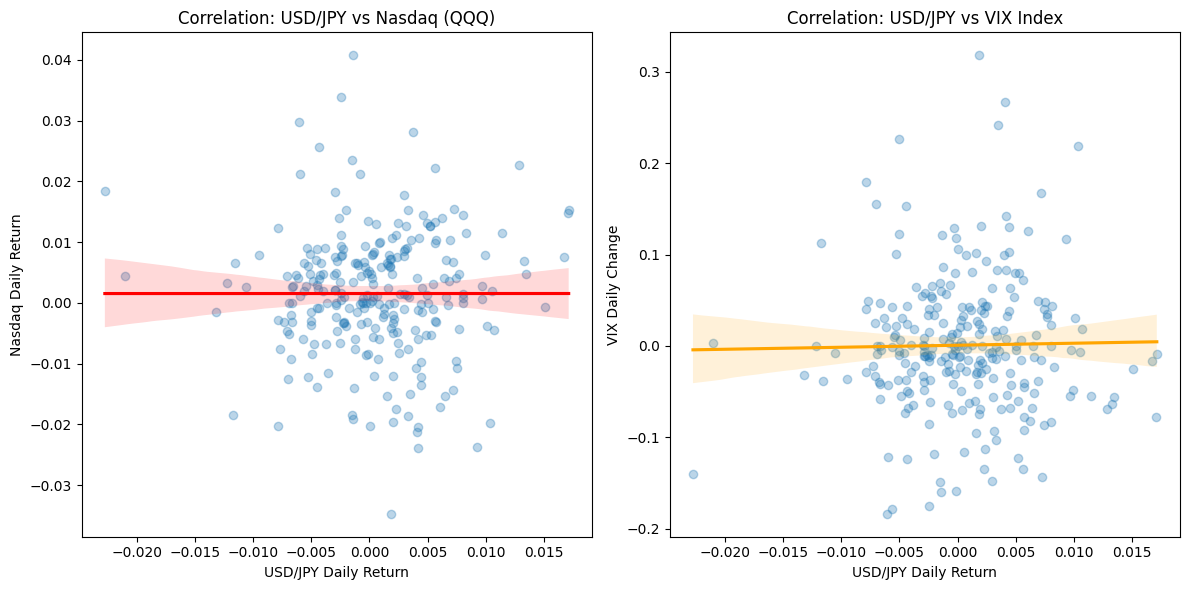


--- Correlation Matrix ---
Ticker      Nasdaq  JPY_Rate       VIX
Ticker                                
Nasdaq    1.000000  0.000086 -0.798121
JPY_Rate  0.000086  1.000000  0.016979
VIX      -0.798121  0.016979  1.000000


In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Loading (USD/JPY, Nasdaq, VIX)
# USDJPY=X: 1 USD to JPY (Lower = JPY Strength / Unwinding Signal)
print("--- Downloading Market Data ---")
tickers = {'USDJPY=X': 'JPY_Rate', 'QQQ': 'Nasdaq', '^VIX': 'VIX'}
raw_data = yf.download(list(tickers.keys()), period='1y', auto_adjust=True)['Close']
data = raw_data.rename(columns=tickers)

# 2. Calculate Daily Returns and Changes
returns = data.pct_change().dropna()

# 3. Define 'Unwinding Regime'
# Significant JPY Strength is defined as a >1% drop in USD/JPY rate
unwind_days = returns[returns['JPY_Rate'] <= -0.01].copy()

print("\n" + "="*50)
print("   [JPY Unwinding Days & Market Reaction]   ")
print("="*50)
if not unwind_days.empty:
    print(unwind_days[['JPY_Rate', 'Nasdaq', 'VIX']].tail(10))
else:
    print("No significant JPY unwinding events detected in the last year.")
print("="*50)

# 4. Visualization: Correlation Analysis
plt.figure(figsize=(12, 6))

# Subplot 1: JPY Rate vs Nasdaq (Measuring Equity Impact)
plt.subplot(1, 2, 1)
sns.regplot(x=returns['JPY_Rate'], y=returns['Nasdaq'], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Correlation: USD/JPY vs Nasdaq (QQQ)')
plt.xlabel('USD/JPY Daily Return')
plt.ylabel('Nasdaq Daily Return')

# Subplot 2: JPY Rate vs VIX (Measuring Volatility Spillover)
plt.subplot(1, 2, 2)
sns.regplot(x=returns['JPY_Rate'], y=returns['VIX'], scatter_kws={'alpha':0.3}, line_kws={'color':'orange'})
plt.title('Correlation: USD/JPY vs VIX Index')
plt.xlabel('USD/JPY Daily Return')
plt.ylabel('VIX Daily Change')

plt.tight_layout()
plt.show()

# 5. Output Correlation Matrix
correlation_matrix = returns.corr()
print("\n--- Correlation Matrix ---")
print(correlation_matrix)